Accuracy: 0.89
[[50  2]
 [ 7 21]]


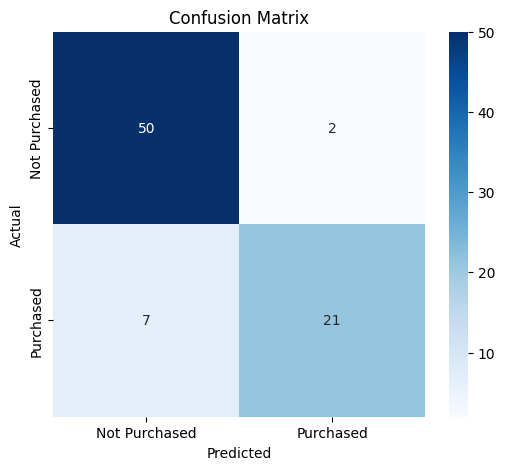

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("Files/Social_Network_Ads.csv")

# Convert Gender to numeric
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# Drop User ID (not useful)
df.drop(columns=["User ID"], inplace=True)

# Features and Target
x = df[["Gender", "Age", "EstimatedSalary"]]
y = df["Purchased"]

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# Scale
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model
model = LogisticRegression()
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)


plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Purchased", "Purchased"], yticklabels=["Not Purchased", "Purchased"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()